<a href="https://colab.research.google.com/github/slendrac123/I.A.-y-Mini-Robots/blob/main/6.Machine_Learning/actividad4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Actividad 4 – Árboles de Decisión
**Algoritmo:** Decision Tree Classifier  
**Dataset:** Iris (UCI / sklearn)  

---

## 1. ¿Qué es un Árbol de Decisión?

Un **Árbol de Decisión** (Decision Tree) es un algoritmo de aprendizaje supervisado que puede usarse tanto para **clasificación** como para **regresión**. Su estructura imita el proceso de toma de decisiones humano: a partir de una pregunta sobre un atributo (feature), el árbol se ramifica hacia nodos hijos hasta llegar a una hoja que contiene la predicción final.

### Componentes del árbol
| Componente | Descripción |
|---|---|
| **Nodo raíz** | Primera división; usa el atributo más informativo |
| **Nodos internos** | Cada pregunta sobre un atributo |
| **Ramas** | Posibles respuestas a cada pregunta |
| **Hojas** | Predicción final (clase o valor) |

### ¿Cómo elige el árbol qué atributo usar primero?
Usa criterios de **impureza**:
- **Gini**: mide la probabilidad de clasificar incorrectamente un elemento aleatorio.  
  `Gini = 1 - Σ(pᵢ²)`
- **Entropía (Información)**: mide el desorden en un nodo.  
  `H = -Σ(pᵢ · log₂(pᵢ))`
- El atributo que **más reduce** la impureza se elige primero (**Information Gain**).

### Ventajas
- Fácil de interpretar y visualizar
- No requiere normalización de los datos
- Maneja datos numéricos y categóricos
- Rápido en predicción

### Desventajas
- Propenso al **sobreajuste** (overfitting) si no se limita su profundidad
- Inestable: pequeños cambios en los datos pueden cambiar la estructura del árbol
- Puede crear árboles sesgados si las clases están desbalanceadas

### Hiperparámetros clave en scikit-learn
| Parámetro | Qué controla |
|---|---|
| `max_depth` | Profundidad máxima del árbol (evita overfitting) |
| `min_samples_split` | Mínimo de muestras para dividir un nodo |
| `min_samples_leaf` | Mínimo de muestras en una hoja |
| `criterion` | Criterio de impureza: `'gini'` o `'entropy'` |
| `max_features` | Número de atributos considerados en cada división |


---
## 2. Dataset: Iris

El dataset **Iris** (Fisher, 1936) es uno de los más utilizados en ML para clasificación.  
Contiene **150 muestras** de flores de iris con **4 atributos** numéricos y **3 clases** de salida.

| Atributo | Descripción |
|---|---|
| `sepal length (cm)` | Longitud del sépalo |
| `sepal width (cm)` | Ancho del sépalo |
| `petal length (cm)` | Longitud del pétalo |
| `petal width (cm)` | Ancho del pétalo |

**Clases:** Iris-Setosa (0), Iris-Versicolor (1), Iris-Virginica (2)

In [46]:
# ── Importación de librerías ──────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings('ignore')
print('Librerías importadas correctamente ✓')

Librerías importadas correctamente ✓


In [47]:
# ── Carga y exploración del dataset ─────────────────────────────────────────
iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = pd.Series(iris.target, name='clase')

print(f'Forma del dataset: {X.shape}  →  {X.shape[0]} muestras, {X.shape[1]} atributos')
print(f'Clases: {iris.target_names}\n')
print('Primeras 5 filas:')
display(X.head())
print('\nEstadísticas descriptivas:')
display(X.describe().round(2))

Forma del dataset: (150, 4)  →  150 muestras, 4 atributos
Clases: ['setosa' 'versicolor' 'virginica']

Primeras 5 filas:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2



Estadísticas descriptivas:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.00,150.00,150.00,150.00
mean,5.84,3.06,3.76,1.20
std,0.83,0.44,1.77,0.76
min,4.30,2.00,1.00,0.10
25%,5.10,2.80,1.60,0.30
50%,5.80,3.00,4.35,1.30
75%,6.40,3.30,5.10,1.80
max,7.90,4.40,6.90,2.50


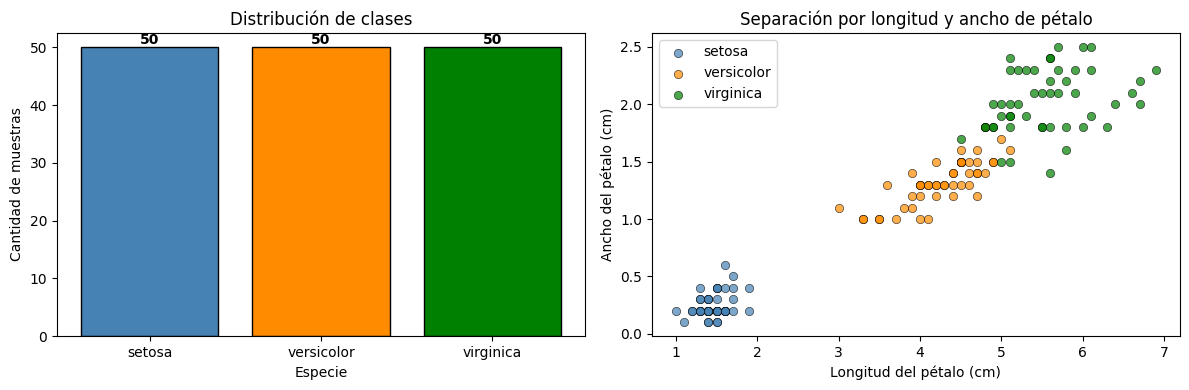

In [48]:
# ── Visualización: distribución de clases ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Conteo por clase
conteo = y.value_counts().sort_index()
axes[0].bar(iris.target_names, conteo.values, color=['steelblue','darkorange','green'], edgecolor='black')
axes[0].set_title('Distribución de clases')
axes[0].set_ylabel('Cantidad de muestras')
axes[0].set_xlabel('Especie')
for i, v in enumerate(conteo.values):
    axes[0].text(i, v + 0.5, str(v), ha='center', fontweight='bold')

# Scatter: longitud vs ancho de pétalo (los 2 atributos más discriminativos)
colores = ['steelblue', 'darkorange', 'green']
for clase in range(3):
    idx = y == clase
    axes[1].scatter(X.loc[idx, 'petal length (cm)'],
                    X.loc[idx, 'petal width (cm)'],
                    label=iris.target_names[clase],
                    color=colores[clase], alpha=0.7, edgecolors='black', linewidth=0.5)
axes[1].set_xlabel('Longitud del pétalo (cm)')
axes[1].set_ylabel('Ancho del pétalo (cm)')
axes[1].set_title('Separación por longitud y ancho de pétalo')
axes[1].legend()

plt.tight_layout()
plt.show()

# PASO 4: Preprocesamiento - División del dataset
---
## 3. Preprocesamiento: División del dataset

Dividimos el dataset en **entrenamiento (70%)** y **prueba (30%)**.  
Con `stratify=y` garantizamos que la proporción de clases se mantenga en ambas particiones.

In [49]:
# ── División entrenamiento / prueba ──────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,       # 30% para prueba
    random_state=42,      # semilla para reproducibilidad
    stratify=y            # mantiene la proporción de clases
)

print(f'Tamaño entrenamiento : {X_train.shape[0]} muestras')
print(f'Tamaño prueba        : {X_test.shape[0]} muestras')
print(f'\nDistribución de clases en entrenamiento:\n{y_train.value_counts().sort_index()}')

Tamaño entrenamiento : 105 muestras
Tamaño prueba        : 45 muestras

Distribución de clases en entrenamiento:
clase
0    35
1    35
2    35
Name: count, dtype: int64


---
## 4. Entrenamiento del modelo

Entrenamos dos variantes para comparar el efecto del hiperparámetro `max_depth`:
- **Árbol sin límite** (puede generar overfitting)
- **Árbol con `max_depth=3`** (más generalizable)

In [50]:
# ── Entrenamiento: dos variantes ─────────────────────────────────────────────

# Variante 1: sin restricción de profundidad
dt_completo = DecisionTreeClassifier(criterion='gini', random_state=42)
dt_completo.fit(X_train, y_train)

# Variante 2: profundidad máxima = 3
dt_podado = DecisionTreeClassifier(criterion='gini', max_depth=3, random_state=42)
dt_podado.fit(X_train, y_train)

print('Modelos entrenados:')
print(f'  Árbol completo  → profundidad real: {dt_completo.get_depth()}')
print(f'  Árbol podado    → profundidad real: {dt_podado.get_depth()}')

Modelos entrenados:
  Árbol completo  → profundidad real: 5
  Árbol podado    → profundidad real: 3


---
## 5. Visualización del árbol de decisión

El árbol podado (`max_depth=3`) es interpretable a simple vista. Cada nodo muestra:
- La **condición de división** (feature ≤ umbral)
- El valor de **impureza Gini**
- El número de **muestras** en ese nodo
- La **distribución** por clase y la **predicción** si fuera hoja

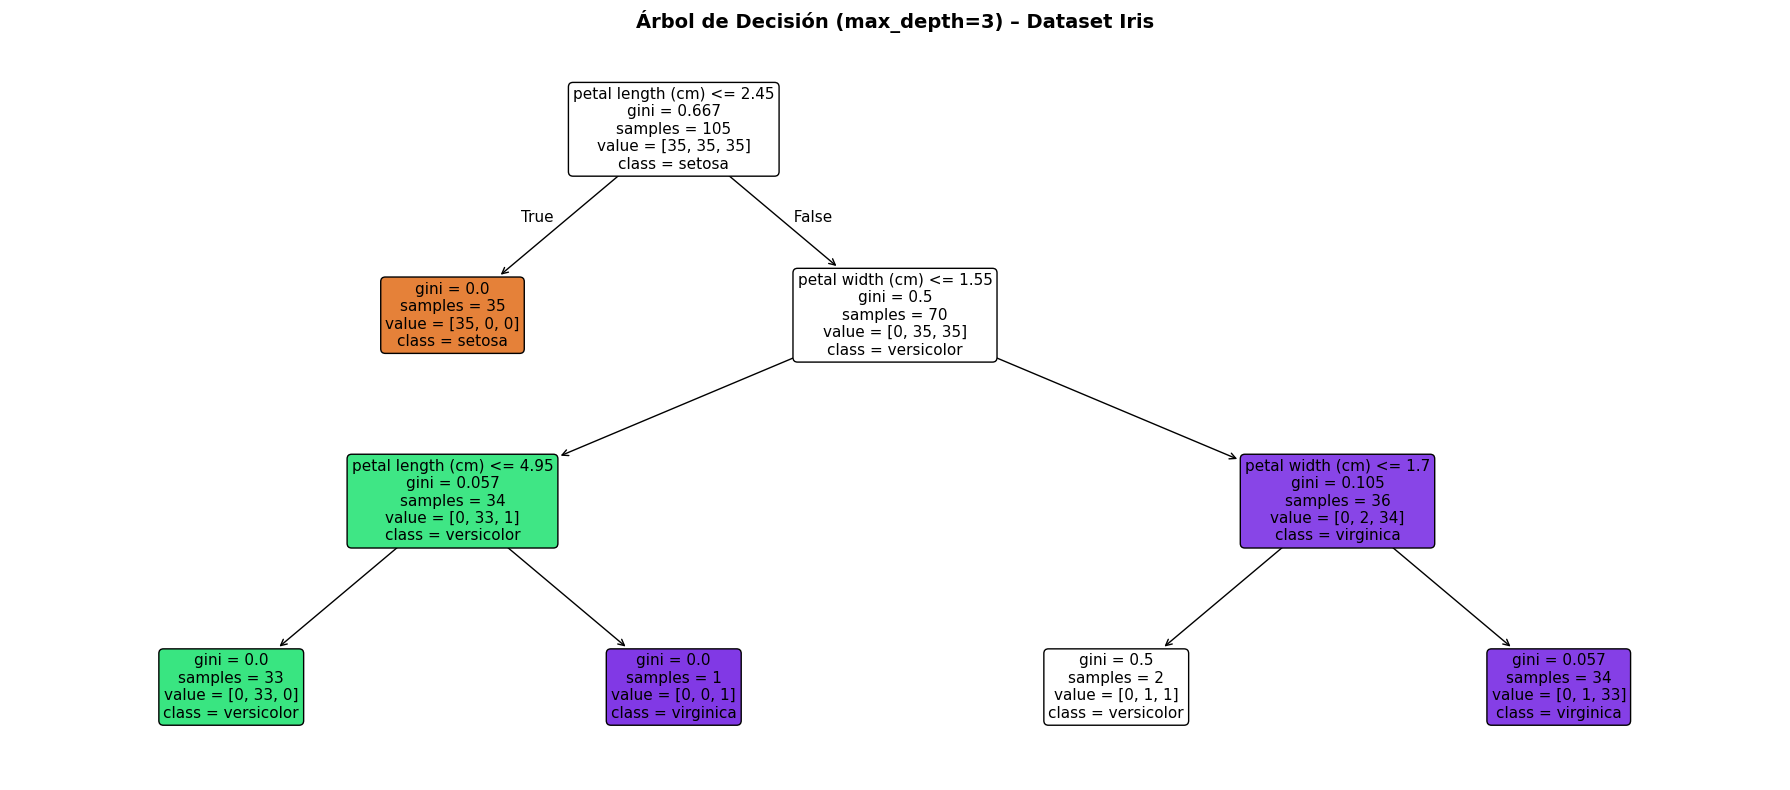


Representación en texto del árbol podado:
|--- petal length (cm) <= 2.45
|   |--- class: 0
|--- petal length (cm) >  2.45
|   |--- petal width (cm) <= 1.55
|   |   |--- petal length (cm) <= 4.95
|   |   |   |--- class: 1
|   |   |--- petal length (cm) >  4.95
|   |   |   |--- class: 2
|   |--- petal width (cm) >  1.55
|   |   |--- petal width (cm) <= 1.70
|   |   |   |--- class: 1
|   |   |--- petal width (cm) >  1.70
|   |   |   |--- class: 2



In [51]:
# ── Visualización gráfica del árbol podado ───────────────────────────────────
fig, ax = plt.subplots(figsize=(18, 8))
plot_tree(
    dt_podado,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True,          # colorea los nodos según la clase predominante
    rounded=True,
    fontsize=11,
    ax=ax
)
ax.set_title('Árbol de Decisión (max_depth=3) – Dataset Iris', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Representación en texto
print('\nRepresentación en texto del árbol podado:')
print(export_text(dt_podado, feature_names=iris.feature_names))

---
## 6. Evaluación del modelo

Usamos:
- **Precisión (Accuracy)**: porcentaje de predicciones correctas
- **Reporte de clasificación**: precisión, recall y F1 por clase
- **Matriz de Confusión**: visualiza los errores de clasificación


In [52]:
# ── Predicciones y métricas ───────────────────────────────────────────────────
for nombre, modelo in [('Árbol completo', dt_completo), ('Árbol podado (depth=3)', dt_podado)]:
    y_pred = modelo.predict(X_test)
    acc_train = accuracy_score(y_train, modelo.predict(X_train))
    acc_test  = accuracy_score(y_test, y_pred)

    print(f'{'='*55}')
    print(f'  {nombre}')
    print(f'{'='*55}')
    print(f'  Precisión en entrenamiento : {acc_train:.4f} ({acc_train*100:.2f}%)')
    print(f'  Precisión en prueba        : {acc_test:.4f} ({acc_test*100:.2f}%)')
    if acc_train - acc_test > 0.05:
        print('  ⚠ Posible SOBREAJUSTE (overfitting)')
    print(f'\n  Reporte de clasificación (prueba):')
    print(classification_report(y_test, y_pred, target_names=iris.target_names, digits=3))

  Árbol completo
  Precisión en entrenamiento : 1.0000 (100.00%)
  Precisión en prueba        : 0.9333 (93.33%)
  ⚠ Posible SOBREAJUSTE (overfitting)

  Reporte de clasificación (prueba):
              precision    recall  f1-score   support

      setosa      1.000     1.000     1.000        15
  versicolor      1.000     0.800     0.889        15
   virginica      0.833     1.000     0.909        15

    accuracy                          0.933        45
   macro avg      0.944     0.933     0.933        45
weighted avg      0.944     0.933     0.933        45

  Árbol podado (depth=3)
  Precisión en entrenamiento : 0.9810 (98.10%)
  Precisión en prueba        : 0.9778 (97.78%)

  Reporte de clasificación (prueba):
              precision    recall  f1-score   support

      setosa      1.000     1.000     1.000        15
  versicolor      1.000     0.933     0.966        15
   virginica      0.938     1.000     0.968        15

    accuracy                          0.978        45
  

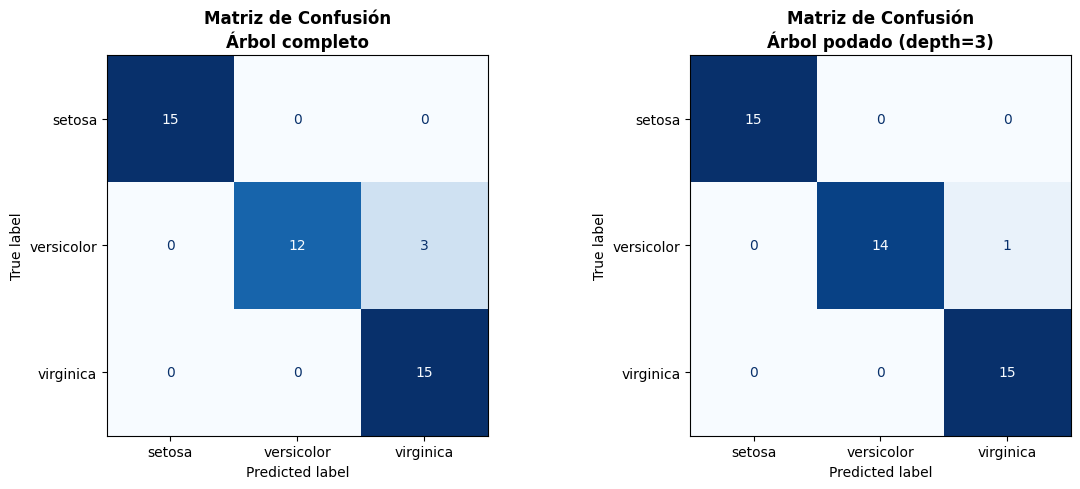

Interpretación de la Matriz de Confusión:
  VP (diagonal): predicciones correctas por clase
  FP/FN (fuera de diagonal): errores de clasificación


In [53]:
# ── Matriz de Confusión ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (nombre, modelo) in zip(axes, [('Árbol completo', dt_completo), ('Árbol podado (depth=3)', dt_podado)]):
    y_pred = modelo.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=iris.target_names)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'Matriz de Confusión\n{nombre}', fontweight='bold')

plt.tight_layout()
plt.show()

print('Interpretación de la Matriz de Confusión:')
print('  VP (diagonal): predicciones correctas por clase')
print('  FP/FN (fuera de diagonal): errores de clasificación')

---
## 7. Importancia de los atributos (Feature Importance)

El árbol de decisión asigna a cada atributo una **importancia** proporcional a cuánto redujo la impureza (Gini) en todas las divisiones donde fue utilizado.

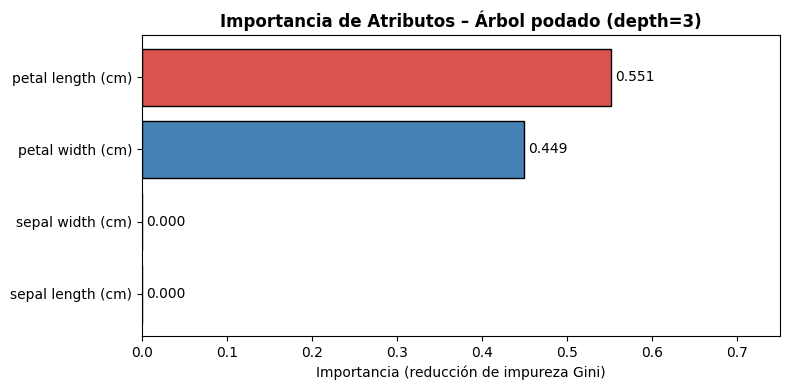


Atributo más importante: petal length (cm)
→ Este atributo es el más discriminativo para separar las 3 especies de iris.


In [54]:
# ── Importancia de atributos ─────────────────────────────────────────────────
importancias = pd.Series(dt_podado.feature_importances_, index=iris.feature_names)
importancias = importancias.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 4))
colores = ['#d9534f' if v == importancias.max() else 'steelblue' for v in importancias.values]
bars = ax.barh(importancias.index, importancias.values, color=colores, edgecolor='black')
for bar, val in zip(bars, importancias.values):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=10)
ax.set_xlabel('Importancia (reducción de impureza Gini)')
ax.set_title('Importancia de Atributos – Árbol podado (depth=3)', fontweight='bold')
ax.set_xlim(0, 0.75)
plt.tight_layout()
plt.show()

print('\nAtributo más importante:', importancias.idxmax())
print('→ Este atributo es el más discriminativo para separar las 3 especies de iris.')

---
## 8. Efecto de max_depth sobre la precisión (Análisis adicional)

Exploramos cómo varía la precisión en entrenamiento y prueba a medida que aumentamos `max_depth`.  
Esto ilustra visualmente el fenómeno de **overfitting**.

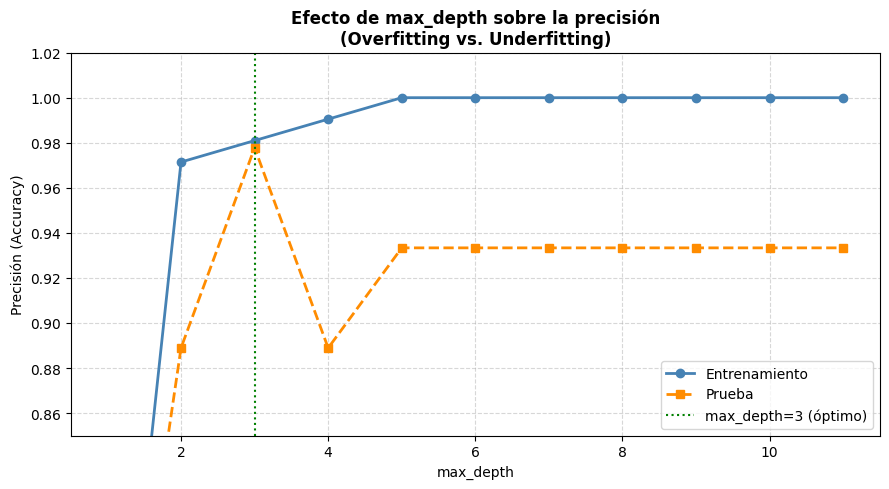

Observación:
  - Para max_depth pequeño: el modelo no aprende suficiente (underfitting)
  - Para max_depth grande: el modelo memoriza los datos de entrenamiento (overfitting)
  - El punto óptimo balancea ambos efectos


In [55]:
# ── Curva de complejidad ──────────────────────────────────────────────────────
profundidades = range(1, 12)
acc_train_list, acc_test_list = [], []

for d in profundidades:
    dt = DecisionTreeClassifier(max_depth=d, random_state=42)
    dt.fit(X_train, y_train)
    acc_train_list.append(accuracy_score(y_train, dt.predict(X_train)))
    acc_test_list.append(accuracy_score(y_test, dt.predict(X_test)))

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(profundidades, acc_train_list, 'o-', color='steelblue', label='Entrenamiento', linewidth=2)
ax.plot(profundidades, acc_test_list,  's--', color='darkorange', label='Prueba', linewidth=2)
ax.axvline(x=3, color='green', linestyle=':', linewidth=1.5, label='max_depth=3 (óptimo)')
ax.set_xlabel('max_depth')
ax.set_ylabel('Precisión (Accuracy)')
ax.set_title('Efecto de max_depth sobre la precisión\n(Overfitting vs. Underfitting)', fontweight='bold')
ax.legend()
ax.set_ylim(0.85, 1.02)
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print('Observación:')
print('  - Para max_depth pequeño: el modelo no aprende suficiente (underfitting)')
print('  - Para max_depth grande: el modelo memoriza los datos de entrenamiento (overfitting)')
print('  - El punto óptimo balancea ambos efectos')

---
## 9. Validación cruzada (Cross-Validation)

La validación cruzada de k-pliegues (k-fold cross-validation) divide el dataset en k partes,  
entrenando k veces y usando cada parte como conjunto de prueba una vez.  
Esto da una estimación más robusta de la precisión real del modelo.

In [56]:
# PASO 10: Realización de validación cruzada 5-fold
# ── Validación cruzada 5-fold ────────────────────────────────────────────────
dt_final = DecisionTreeClassifier(criterion='gini', max_depth=3, random_state=42)
scores = cross_val_score(dt_final, X, y, cv=5, scoring='accuracy')

print('Resultados de validación cruzada (5 pliegues):')
for i, s in enumerate(scores, 1):
    print(f'  Pliegue {i}: {s:.4f} ({s*100:.2f}%)')
print(f'\n  Precisión media  : {scores.mean():.4f} ± {scores.std():.4f}')
print(f'  Interpretación   : el modelo clasifica correctamente ~{scores.mean()*100:.1f}% de las muestras')

Resultados de validación cruzada (5 pliegues):
  Pliegue 1: 0.9667 (96.67%)
  Pliegue 2: 0.9667 (96.67%)
  Pliegue 3: 0.9333 (93.33%)
  Pliegue 4: 1.0000 (100.00%)
  Pliegue 5: 1.0000 (100.00%)

  Precisión media  : 0.9733 ± 0.0249
  Interpretación   : el modelo clasifica correctamente ~97.3% de las muestras


---
## 10. Predicción con nuevos datos

Simulamos la llegada de una **nueva instancia** (flor desconocida) y usamos el modelo para predecir su especie.

In [57]:
# ── Predicción en producción ─────────────────────────────────────────────────
dt_final.fit(X_train, y_train)  # entrenamiento final

# Nueva flor a clasificar (valores ajustados para buscar una predicción menos certera)
nueva_flor = pd.DataFrame(
    [[6.0, 3.0, 5.0, 1.6]], # Valores cerca de los límites de decisión entre Versicolor y Virginica
    columns=iris.feature_names
)

clase_pred = dt_final.predict(nueva_flor)[0]
proba_pred = dt_final.predict_proba(nueva_flor)[0]

print('Nueva flor a clasificar:')
print(nueva_flor.to_string(index=False))
print(f'\nPredicción del modelo : {iris.target_names[clase_pred]} (clase {clase_pred})')
print('\nProbabilidad por clase:')
for nombre, prob in zip(iris.target_names, proba_pred):
    barra = '█' * int(prob * 40)
    print(f'  {nombre:<20} {barra:<40} {prob:.2%}')

Nueva flor a clasificar:
 sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
               6.0               3.0                5.0               1.6

Predicción del modelo : versicolor (clase 1)

Probabilidad por clase:
  setosa                                                        0.00%
  versicolor           ████████████████████                     50.00%
  virginica            ████████████████████                     50.00%


---
## 12. Optimización de Hiperparámetros con `GridSearchCV`

Aunque hemos explorado `max_depth` manualmente, una forma más sistemática de encontrar los mejores hiperparámetros es usando **`GridSearchCV`**. Esta técnica prueba todas las combinaciones de un conjunto de hiperparámetros y realiza validación cruzada para cada una, seleccionando la que obtiene la mejor puntuación.

In [58]:
# ── Optimización con GridSearchCV ───────────────────────────────────────────
from sklearn.model_selection import GridSearchCV

# Definir el espacio de búsqueda para los hiperparámetros
param_grid = {
    'max_depth': range(1, 10), # Profundidades de 1 a 9
    'min_samples_leaf': [1, 2, 3, 4, 5], # Mínimo de muestras en una hoja
    'criterion': ['gini', 'entropy'] # Criterios de impureza
}

# Crear el modelo base
dt_base = DecisionTreeClassifier(random_state=42)

# Configurar GridSearchCV
# cv=5: 5-fold cross-validation
# scoring='accuracy': Métrica a optimizar
# n_jobs=-1: Usar todos los núcleos disponibles de la CPU
grid_search = GridSearchCV(dt_base, param_grid, cv=5, scoring='accuracy', n_jobs=-1)

# Ejecutar la búsqueda en la cuadrícula
grid_search.fit(X_train, y_train)

print(f'Mejores hiperparámetros: {grid_search.best_params_}')
print(f'Mejor precisión en CV : {grid_search.best_score_:.4f}')

Mejores hiperparámetros: {'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 1}
Mejor precisión en CV : 0.9524


---
## 13. Modelo final con hiperparámetros optimizados

Ahora, entrenamos un modelo con los hiperparámetros encontrados por `GridSearchCV` y evaluamos su rendimiento final en el conjunto de prueba.

  Modelo final (GridSearchCV)
  Precisión en entrenamiento : 0.9810 (98.10%)
  Precisión en prueba        : 0.9778 (97.78%)

  Reporte de clasificación (prueba):
              precision    recall  f1-score   support

      setosa      1.000     1.000     1.000        15
  versicolor      1.000     0.933     0.966        15
   virginica      0.938     1.000     0.968        15

    accuracy                          0.978        45
   macro avg      0.979     0.978     0.978        45
weighted avg      0.979     0.978     0.978        45



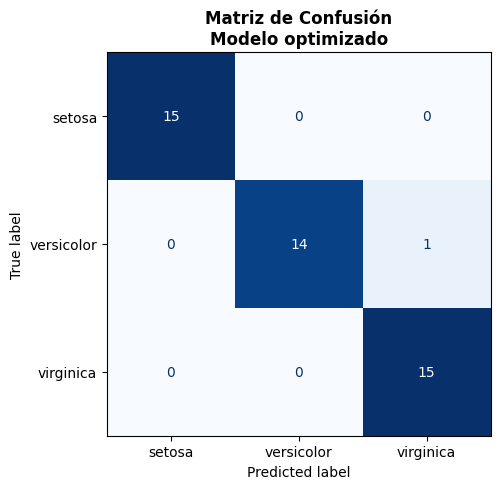

In [59]:
# ── Entrenamiento y evaluación del modelo final ─────────────────────────────
# Crear el modelo final con los mejores parámetros
dt_best = grid_search.best_estimator_

# Realizar predicciones en el conjunto de prueba
y_pred_best = dt_best.predict(X_test)

# Calcular métricas
acc_train_best = accuracy_score(y_train, dt_best.predict(X_train))
acc_test_best  = accuracy_score(y_test, y_pred_best)

print(f'{'='*55}')
print(f'  Modelo final (GridSearchCV)')
print(f'{'='*55}')
print(f'  Precisión en entrenamiento : {acc_train_best:.4f} ({acc_train_best*100:.2f}%)')
print(f'  Precisión en prueba        : {acc_test_best:.4f} ({acc_test_best*100:.2f}%)')

print(f'\n  Reporte de clasificación (prueba):')
print(classification_report(y_test, y_pred_best, target_names=iris.target_names, digits=3))

# Matriz de Confusión del modelo optimizado
fig, ax = plt.subplots(figsize=(6, 5))
cm_best = confusion_matrix(y_test, y_pred_best)
disp_best = ConfusionMatrixDisplay(confusion_matrix=cm_best, display_labels=iris.target_names)
disp_best.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Matriz de Confusión\nModelo optimizado', fontweight='bold')
plt.tight_layout()
plt.show()

---
## 11. Conclusiones

1. El **Árbol de Decisión** es un algoritmo intuitivo y visualmente interpretable, ideal para problemas de clasificación supervisada.
2. El hiperparámetro `max_depth` es crítico: valores demasiado altos generan **overfitting** (el modelo memoriza los datos de entrenamiento pero falla con datos nuevos).
3. Para el dataset Iris, un árbol de **profundidad 3** alcanza ~96-97% de precisión en prueba, siendo suficiente para separar las tres especies.
4. Los atributos **longitud del pétalo** y **ancho del pétalo** son los más informativos para esta clasificación.
5. La **validación cruzada** da una estimación más confiable de la precisión real que una sola partición entrenamiento/prueba.
6. La **Matriz de Confusión** permite identificar qué clases se confunden entre sí, información valiosa para mejorar el modelo.

